# (1) Missing values- Feature Engineering

1. Data should be collected from multiple sources.
2. handle missing value first and handling the data completes depends on the data set provided.( 1. Continuous Data--  , 2. Categorical data)
3. What are the different types of missing data-- Missing Completely at Random, MCAR:
A variable is missing completely at random (MCAR) if the probability of being missing is the same for all the observations. When data is MCAR, there is absolutely no relationship between the data missing and any other values, observed or missing, within the dataset. In other words, those missing data points are a random subset of the data. There is nothing systematic going on that makes some data more likely to be missing than other.

In [7]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib as plt 

%matplotlib inline

In [8]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


#### 4.Missing Data Not At Random(MNAR): Systematic missing Values
There is absolutely some relationship between the data missing and any other values, observed or missing, within the dataset.

In [11]:
df['cabin_null']=np.where(df['Cabin'].isnull(),1,0)

## find the percentage of null values
df['cabin_null'].mean()

np.float64(0.7710437710437711)

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'cabin_null'],
      dtype='object')

In [13]:
df['cabin_null']

0      1
1      0
2      1
3      0
4      1
      ..
886    1
887    0
888    1
889    0
890    1
Name: cabin_null, Length: 891, dtype: int64

In [14]:
df.groupby(['Survived'])['cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: cabin_null, dtype: float64

#### Missing At Random(MAR)

### All the techniques for handling missing value
1. mean , median, mode replacement
2. random sampling notation
3. Capture NAN Values witha new feature
4. end of distribution imputation
5. arbitay imputation
6. Frequenr categories imputation

#### Mean / Median / Mode implementation
Mean/Median has the assumption that the data is missing completely at random(MCAR)
We solve this by replacing the NAN with most frequent occurance of variable.

In [15]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv", usecols=['Age','Fare','Survived'])

In [16]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [16]:
## Lets go and see the percentage of missing values.
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [17]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)

In [18]:
median=df.Age.median()
median

28.0

In [19]:
impute_nan(df,'Age',median)
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [20]:
print(df['Age'].std())
print(df['Age_median'].std())

14.526497332334044
13.019696550973194


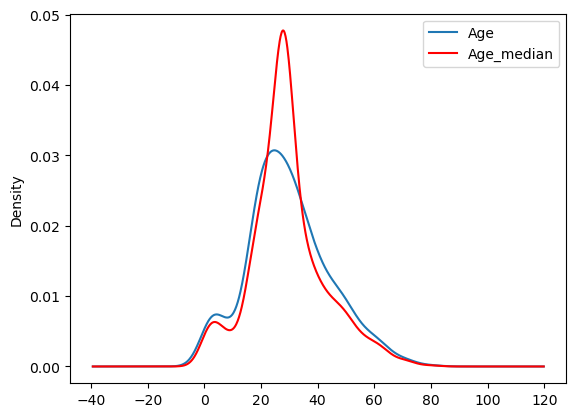

In [ ]:
#kde-- kernal density estimatter
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind='kde', ax=ax)
df.Age_median.plot(kind='kde', ax=ax, color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [22]:
import matplotlib.pyplot as plt

print(type(plt.figure))

<class 'function'>


#### Adavantages----
1. easy to implement
2. faster way to obtain the complete dataset
#### Disadvantages----
1. Change or Distortion in the original variance
2. Impacts correlation

## (2) RANDOM SAMPLE IMPUTATION - uses random observation from the dataset to replace the values

When it should be used?
It assumes that the data are missing completely at random(MCAR)

In [24]:
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [25]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv", usecols=['Age','Fare','Survived'])

In [26]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df['Age'].dropna().sample(df['Age'].isnull().sum(),random_state=0)
# replaces null value with random values , dropna is used so that sample is not picked up from the age dataset

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [31]:
df[df['Age'].isnull()].index

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [39]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)
    df[variable+"_random"]=df[variable]
    random_sample=df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
    ## Pandas need to have same index in order to merge the dataset
    random_sample.index=df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable+'_random']=random_sample

In [40]:
median=df.Age.median()

In [41]:
median

28.0

In [42]:
impute_nan(df,'Age',median)

In [43]:
df.head(20)

,Survived,Age,Fare,Age_median,Age_random
0,0,22.0,7.2500,22.0,22.00
1,1,38.0,71.2833,38.0,38.00
2,1,26.0,7.9250,26.0,26.00
3,1,35.0,53.1000,35.0,35.00
4,0,35.0,8.0500,35.0,35.00
5,0,NaN,8.4583,28.0,28.00
6,0,54.0,51.8625,54.0,54.00
7,0,2.0,21.0750,2.0,2.00
8,1,27.0,11.1333,27.0,27.00
9,1,14.0,30.0708,14.0,14.00


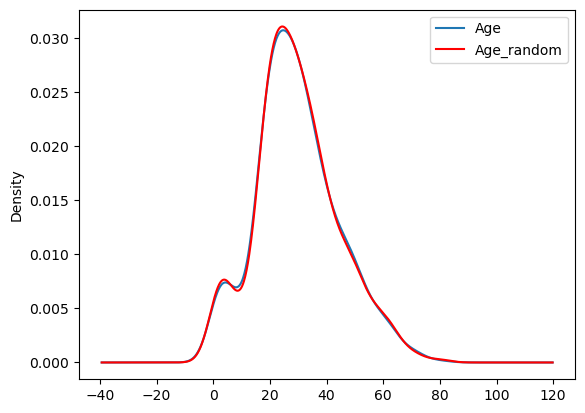

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind='kde', ax=ax)
df.Age_random.plot(kind='kde', ax=ax, color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

#### Advantages
1. Easy to implement
2. there is less distortion in variance
#### Disadvantage
1. Every situation randomness not work, as in business scenario this wont work good.

## (3) CAPTURING NAN VALUES with a new feature
It works well if the data are not missing completely at random.

In [45]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv", usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [46]:
df['Age_NAN']=np.where(df['Age'].isnull(),1,0)

In [47]:
df.head()

,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0


In [48]:
df.Age.median()

28.0

In [50]:
df['Age'].fillna(df.Age.median(), inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_11376\4044525380.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df.Age.median(), inplace=True)


In [51]:
df.head(20)

,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0
5,0,28.0,8.4583,1
6,0,54.0,51.8625,0
7,0,2.0,21.0750,0
8,1,27.0,11.1333,0
9,1,14.0,30.0708,0


##### Adavantages
1. Easy to implement.
2. Captures importance of missing values.
##### Disadvantages
1. Creating Addition Features (Curse of Dimenionality)

### (4) End of distribution imputation

In [52]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv", usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


<Axes: >

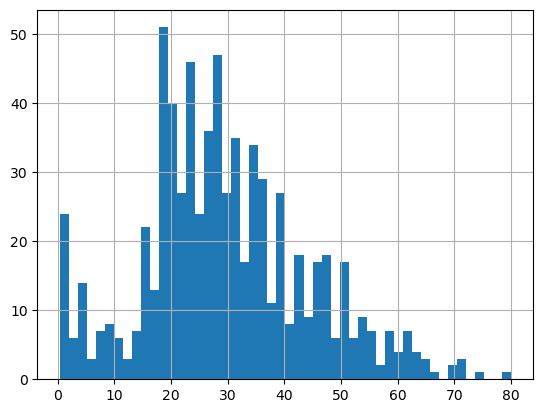

In [55]:
df.Age.hist(bins=50)

In [61]:
extreme=df.Age.mean()+3*df.Age.std()

<Axes: xlabel='Age'>

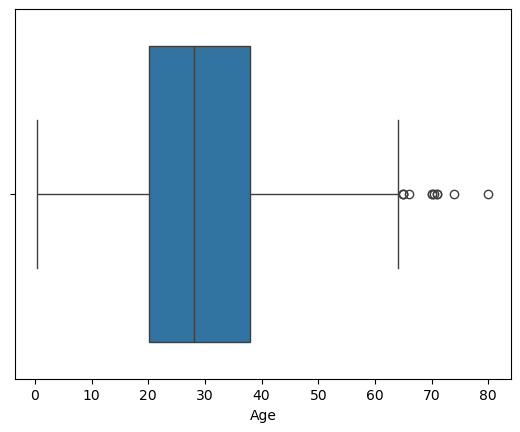

In [60]:
sns.boxplot(x='Age',data =df)

In [62]:
def inpute_nan(df,variable,median,extreme):
    df[variable+"_end_distribution"]=df[variable].fillna(extreme)
    df[variable].fillna(median,inplace=True)

In [64]:
inpute_nan(df,'Age',df.Age.median(),extreme)

C:\Users\Asus\AppData\Local\Temp\ipykernel_11376\1644566081.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[variable].fillna(median,inplace=True)


In [66]:
df.head(10)

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.00000
1,1,38.0,71.2833,38.00000
2,1,26.0,7.9250,26.00000
3,1,35.0,53.1000,35.00000
4,0,35.0,8.0500,35.00000
5,0,28.0,8.4583,73.27861
6,0,54.0,51.8625,54.00000
7,0,2.0,21.0750,2.00000
8,1,27.0,11.1333,27.00000
9,1,14.0,30.0708,14.00000


<Axes: >

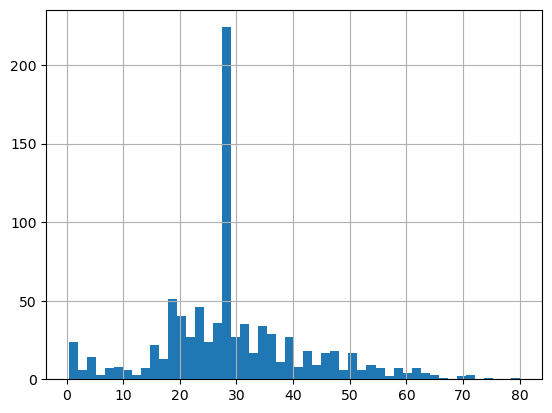

In [67]:
df['Age'].hist(bins=50)

<Axes: >

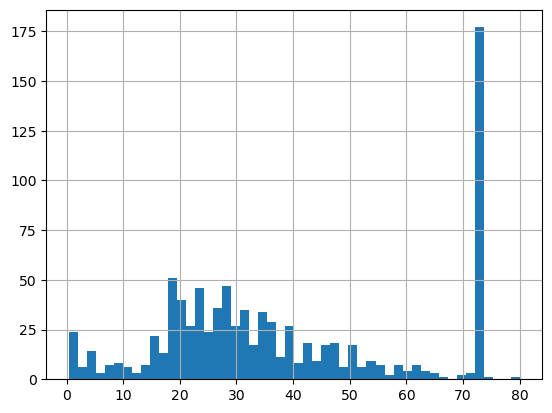

In [68]:
df['Age_end_distribution'].hist(bins=50)

<Axes: xlabel='Age_end_distribution'>

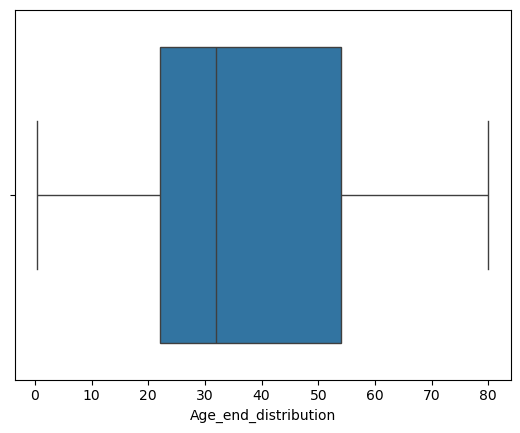

In [69]:
sns.boxplot(x='Age_end_distribution',data=df)

#### Advantages
1. easy to implement.
2. captures the importance of missingess if there is one.
#### Disadvantages
1. distorts the original distribution of the variable.
2. If the missingess is not important, it will mask the predictive power of the original variable by distorting its distribution .
3. if the number of nan is big, it will mask the outliers in the distribution.
4. if the number of nan is small, the replaces nan maybe considered an outlier and pre-processed in a subsequent step of feature engineering.

#### (5) Arbitary Value Imputation
this technique was derived from kaggle competition. 
It consitis of replacing NAN by an arbitary value

In [70]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv", usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [71]:
def inpute_nan(df,variable):
    df[variable+'_hundered']=df[variable].fillna(100)

In [ ]:
#### Arbitary values
##This is not most frequently used, it is used to show the importance of null value.
# hard to decide which value to use
